In [ ]:
from mylib.statistic_test import *
from zfish._io import import16chFlt
from zfish.local_path import *
import os

import numpy as np
import matplotlib.pyplot as plt
from zfish.utils import *

code_id = "5008 - Spatial Preference During Oscillations"
loc = os.path.join(figpath, code_id)
os.makedirs(loc, exist_ok=True)

landmark_pos = [
    (0, 1/18), # Starting Point box
    (2/18, 3/18), # Leaves
    (6/18, 7/18), # Stars
    (8/18, 9/18), # triangles
    (10/18, 11/18), # Polygons
    (14/18, 15/18), # Teeth of Predators
    (16/18, 17/18) # Gravel
]

d:\Software\Anaconda3\envs\maze\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
path = r"D:\EnData\Light-sheet\spatial preference vr1\10162\S2\res.16chFlt"
res = import16chFlt(path)

idx = np.where((res['behav_time'] >= 5)&(res['behav_pos_y'] < 55))[0]
for k in res.keys():
    res[k] = res[k][idx]

behav_pos_y = res['behav_pos_y'] * 2
dx = np.diff(behav_pos_y)
dx[dx<0] += 100
dt = np.diff(res['behav_time']) + 1e-6
speed = np.append(np.abs(dx / dt), 0)

speed_mask = (speed >= 0) & (np.append(dx, 0) < 100)
for k in res.keys():
    res[k] = res[k][speed_mask]
speed = speed[speed_mask]

smooth_ch0 = np.convolve(res['fltCh0'], np.ones(201)/201, mode='same')
smooth_ch1 = np.convolve(res['fltCh1'], np.ones(201)/201, mode='same')
smooth_speed = np.convolve(speed, np.ones(201)/201, mode='same')
x = (behav_pos_y // 1).astype(np.int64)

In [ ]:
plt.plot(res['fltCh0'])
plt.plot(-res['fltCh1'])

Text(0.5, 0, 'Position (%)')

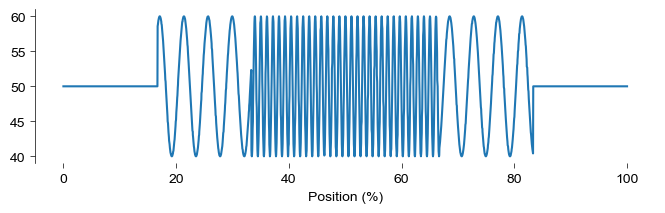

In [ ]:
idx = np.where(res['n_trials'] == 40)[0]
fig = plt.figure(figsize=(8, 2))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right', 'bottom'], ifyticks=True, ifxticks=True)
plt.plot(res['behav_pos_y'][idx]*2, res['behav_pos_x'][idx])
ax.set_xlabel("Position (%)")

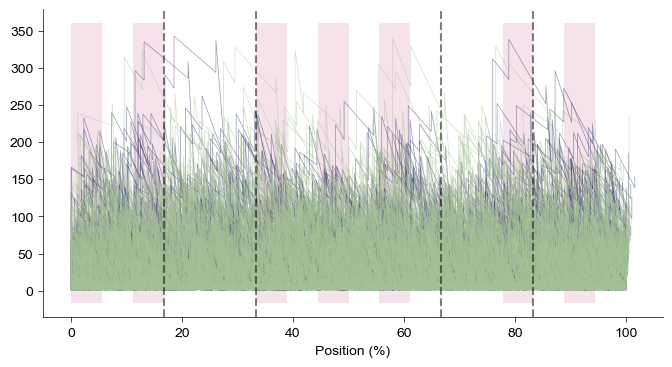

In [ ]:
fig = plt.figure(figsize=(8, 4))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)

dtrials = np.diff(res['n_trials'])
begs = np.concatenate(([0], np.where(dtrials > 0)[0] + 1))
ends = np.concatenate((np.where(dtrials > 0)[0] + 1, [len(res['n_trials'])]))

sns.lineplot(
    
)
for b, e in zip(begs, ends):
    m = res['map'][b]
    color = RemappingPalette[0] if m == 4 else RemappingPalette[1]
    ax.plot(behav_pos_y[b:e], smooth_speed[b:e], color=color, alpha=0.5, linewidth=0.5)
    
ylims = ax.get_ylim()
for i, (start, end) in enumerate(landmark_pos):
    ax.fill_betweenx(ylims, start*100, end*100, color=ChannelColors[0], alpha=0.2, edgecolor=None)
    
ax.set_xlabel('Position (%)')
ax.axvline(1/6*100, color='k', linestyle='--', alpha=0.5)
ax.axvline(2/6*100, color='k', linestyle='--', alpha=0.5)
ax.axvline(4/6*100, color='k', linestyle='--', alpha=0.5)
ax.axvline(5/6*100, color='k', linestyle='--', alpha=0.5)

199


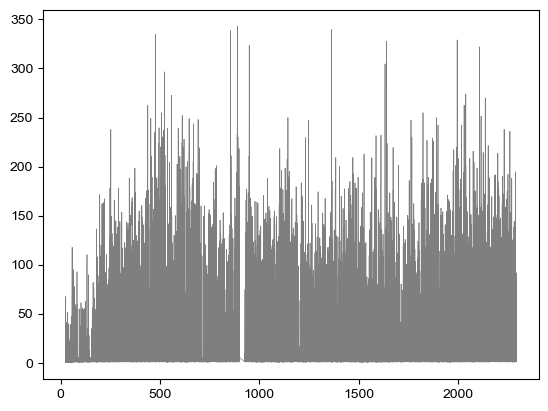

In [38]:
plt.plot(res['behav_time'], smooth_speed, color='k', alpha=0.5, linewidth=0.5)
print(np.max(res['n_trials']))